# ECG Heartbeat Classification Project
## Phase 2 — Heartbeat Segmentation

This notebook segments individual heartbeats from the raw ECG signals
using annotation positions from the MIT-BIH Arrhythmia Database.
Each heartbeat is extracted as a fixed-size window around the R-peak
annotation point, ready for feature extraction in Phase 3.

### Import libraries

In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import Counter


### Define data path and valid beat types

In [2]:
data_path = '../data/mit-bih-arrhythmia-database-1.0.0'

# Valid beat symbols we want to keep (ignoring rhythm markers like +, ~, |)
valid_beats = ['N', 'L', 'R', 'V', 'A', 'F', 'f', 'j', 'a', 'J', 'S', 'E', 'e']

# Window size around each R-peak (in samples)
# 360 samples/sec, so 180 before + 180 after = 1 second per beat
before = 180
after = 180
window_size = before + after  # = 360 samples per heartbeat

print(f"Window size per beat: {window_size} samples = 1 second")
print(f"Valid beat types: {valid_beats}")

Window size per beat: 360 samples = 1 second
Valid beat types: ['N', 'L', 'R', 'V', 'A', 'F', 'f', 'j', 'a', 'J', 'S', 'E', 'e']


### Segment heartbeats from a single record

In [3]:
def segment_record(record_name, data_path, before, after, valid_beats):
    beats = []
    labels = []
    
    try:
        # Load the ECG signal
        record = wfdb.rdrecord(os.path.join(data_path, record_name))
        signal = record.p_signal[:, 0]  # MLII lead only
        
        # Load annotations
        annotation = wfdb.rdann(os.path.join(data_path, record_name), 'atr')
        
        # Loop through every annotation
        for i, (sample, symbol) in enumerate(zip(annotation.sample, annotation.symbol)):
            
            # Skip if not a valid beat type
            if symbol not in valid_beats:
                continue
            
            # Skip if too close to start or end of recording
            if sample - before < 0 or sample + after >= len(signal):
                continue
            
            # Cut out the window around the R-peak
            beat = signal[sample - before : sample + after]
            
            beats.append(beat)
            labels.append(symbol)
    
    except Exception as e:
        print(f"Could not process record {record_name}: {e}")
    
    return beats, labels

print("Segmentation function defined!")

Segmentation function defined!


### What Cell 3 does:
In simple terms, The raw ECG signal is a long strip, and this function cuts out identical sized pieces, one piece per heartbeat.
step by step inside the function:
1. It loads the ECG signal and annotations for one record (e.g. record 100)
2. It loops through every single annotation — every heartbeat marker
3. For each annotation it asks three questions:

Is this a real heartbeat symbol? If not: skip it (filters out +, ~ etc)
Is it too close to the start or end of the recording? If yes: skip it (avoids cutting outside the signal)
If both checks pass: cut out 360 samples centred on that R-peak

4. It saves each cut piece into beats list and its label into labels list
So after running this on record 100, we get ~2200 individual beat shapes each exactly 360 samples long.

In [6]:
# Test on record 100 first
beats, labels = segment_record('100', data_path, before, after, valid_beats)

print(f"Total beats extracted: {len(beats)}")
print(f"Each beat shape: {beats[0].shape}")
print(f"Label distribution: {Counter(labels)}")

Total beats extracted: 2271
Each beat shape: (360,)
Label distribution: Counter({'N': 2237, 'A': 33, 'V': 1})


### Visualise a single segmented heartbeat

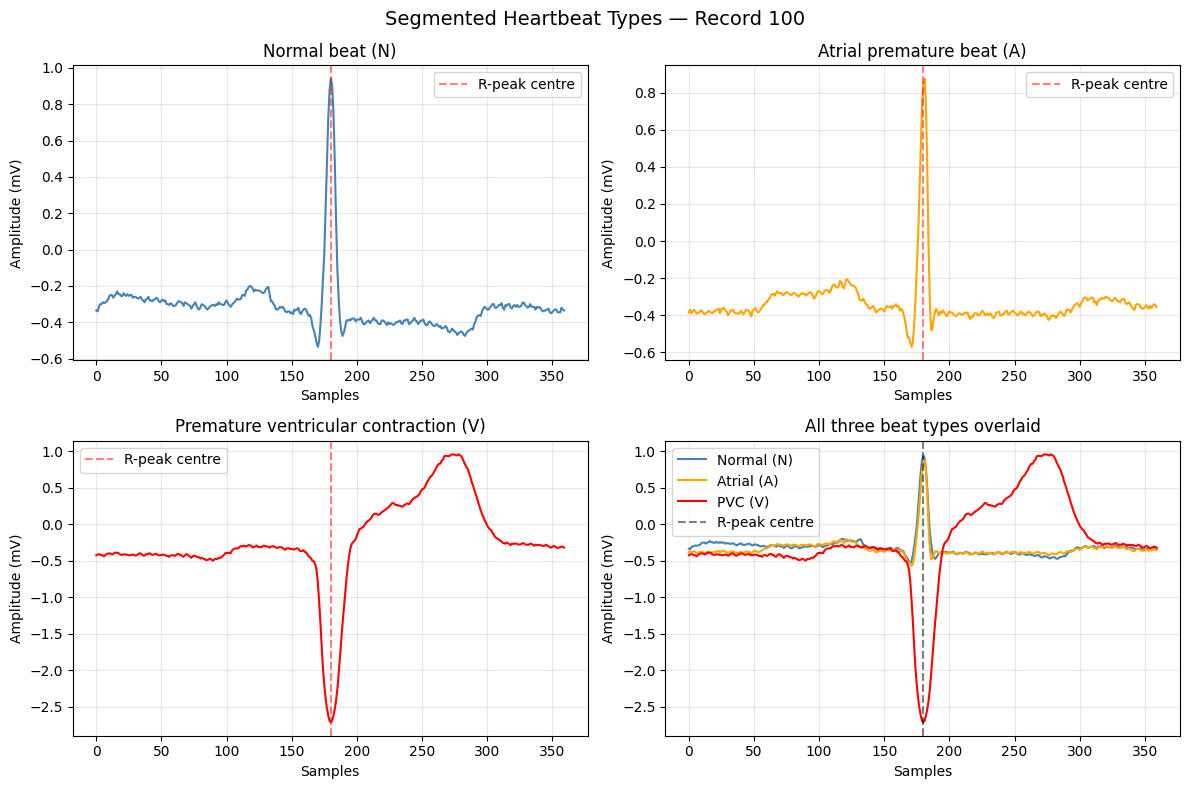

In [8]:
# Plot first Normal beat
plt.figure(figsize=(12, 8))

# Normal beat
plt.subplot(2, 2, 1)
normal_indices = [i for i, l in enumerate(labels) if l == 'N']
plt.plot(beats[normal_indices[0]], color='steelblue', linewidth=1.5)
plt.title('Normal beat (N)')
plt.xlabel('Samples')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.axvline(x=180, color='red', linestyle='--', alpha=0.5, label='R-peak centre')
plt.legend()

# Atrial Premature beat
plt.subplot(2, 2, 2)
atrial_indices = [i for i, l in enumerate(labels) if l == 'A']
plt.plot(beats[atrial_indices[0]], color='orange', linewidth=1.5)
plt.title('Atrial premature beat (A)')
plt.xlabel('Samples')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.axvline(x=180, color='red', linestyle='--', alpha=0.5, label='R-peak centre')
plt.legend()

# PVC beat
plt.subplot(2, 2, 3)
pvc_indices = [i for i, l in enumerate(labels) if l == 'V']
plt.plot(beats[pvc_indices[0]], color='red', linewidth=1.5)
plt.title('Premature ventricular contraction (V)')
plt.xlabel('Samples')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.axvline(x=180, color='red', linestyle='--', alpha=0.5, label='R-peak centre')
plt.legend()

# Overlay all three for comparison
plt.subplot(2, 2, 4)
plt.plot(beats[normal_indices[0]], color='steelblue', linewidth=1.5, label='Normal (N)')
plt.plot(beats[atrial_indices[0]], color='orange', linewidth=1.5, label='Atrial (A)')
plt.plot(beats[pvc_indices[0]], color='red', linewidth=1.5, label='PVC (V)')
plt.title('All three beat types overlaid')
plt.xlabel('Samples')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.axvline(x=180, color='black', linestyle='--', alpha=0.5, label='R-peak centre')
plt.legend()

plt.suptitle('Segmented Heartbeat Types — Record 100', fontsize=14)
plt.tight_layout()
plt.show()

### Observations from segmented heartbeat visualisation

The plot above shows three individual heartbeat types extracted from record 100:

- **Normal beat (N):** Sharp, narrow R-peak at the centre (sample 180).
  Clean P wave visible before the peak and T wave after.
  
- **Atrial Premature beat (A):** Similar shape to Normal but with a slightly
  different baseline and peak morphology. The top chamber fired too early,
  causing a subtle but detectable difference in the waveform shape.

- **Premature Ventricular Contraction (V):** Visually very distinct —
  wider, rounder peak with no clear P wave before it. The bottom chamber
  fired independently, producing a completely different electrical pattern.

The overlaid comparison confirms that N and A are visually similar,
which will make classification challenging. V is clearly distinguishable
by its unique morphology. This visual difference is what the machine
learning model will learn to detect automatically in Phase 4.

### Process all 48 records and build the complete dataset

In [15]:
# Get all record names
all_records = []
for f in os.listdir(data_path):
    if f.endswith('.hea'):
        all_records.append(f.replace('.hea', ''))

all_records = sorted(all_records)
print(f"Total records found: {len(all_records)}")


# Loop through all records
all_beats = []
all_labels = []

for rec_name in all_records:
    beats, labels = segment_record(rec_name, data_path, before, after, valid_beats)
    all_beats.extend(beats)
    all_labels.extend(labels)
    print(f"  Record {rec_name}: {len(beats)} beats extracted")


print(f"Total beats extracted: {len(all_beats)}")
print(f"Total labels: {len(all_labels)}")

Total records found: 48
  Record 100: 2271 beats extracted
  Record 101: 1862 beats extracted
  Record 102: 159 beats extracted
  Record 103: 2083 beats extracted
  Record 104: 831 beats extracted
  Record 105: 2567 beats extracted
  Record 106: 2027 beats extracted
  Record 107: 59 beats extracted
  Record 108: 1762 beats extracted
  Record 109: 2530 beats extracted
  Record 111: 2124 beats extracted
  Record 112: 2537 beats extracted
  Record 113: 1793 beats extracted
  Record 114: 1879 beats extracted
  Record 115: 1951 beats extracted
  Record 116: 2411 beats extracted
  Record 117: 1534 beats extracted
  Record 118: 2277 beats extracted
  Record 119: 1987 beats extracted
  Record 121: 1861 beats extracted
  Record 122: 2474 beats extracted
  Record 123: 1517 beats extracted
  Record 124: 1618 beats extracted
  Record 200: 2600 beats extracted
  Record 201: 1962 beats extracted
  Record 202: 2135 beats extracted
  Record 203: 2975 beats extracted
  Record 205: 2655 beats extracted


### Convert to numpy arrays and check distribution

In [11]:
# Convert to numpy arrays
X = np.array(all_beats)
y = np.array(all_labels)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nWhat X looks like:")
print(f"  Rows = number of beats: {X.shape[0]}")
print(f"  Columns = samples per beat: {X.shape[1]}")

print(f"\nFinal label distribution:")
label_counts = Counter(y)
for symbol, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    percentage = count / len(y) * 100
    print(f"  {symbol}: {count} beats ({percentage:.1f}%)")

X shape: (102382, 360)
y shape: (102382,)

What X looks like:
  Rows = number of beats: 102382
  Columns = samples per beat: 360

Final label distribution:
  N: 75011 beats (73.3%)
  L: 8071 beats (7.9%)
  R: 7255 beats (7.1%)
  V: 7129 beats (7.0%)
  A: 2546 beats (2.5%)
  f: 982 beats (1.0%)
  F: 802 beats (0.8%)
  j: 229 beats (0.2%)
  a: 150 beats (0.1%)
  E: 106 beats (0.1%)
  J: 83 beats (0.1%)
  e: 16 beats (0.0%)
  S: 2 beats (0.0%)


### Map beat labels to Normal vs Abnormal classes

In [12]:
# Map to binary labels: Normal = 0, Abnormal = 1
def map_labels(label):
    if label == 'N':
        return 0  # Normal
    else:
        return 1  # Abnormal

y_binary = np.array([map_labels(label) for label in y])

normal_count = np.sum(y_binary == 0)
abnormal_count = np.sum(y_binary == 1)

print(f"Normal beats (0):   {normal_count} ({normal_count/len(y_binary)*100:.1f}%)")
print(f"Abnormal beats (1): {abnormal_count} ({abnormal_count/len(y_binary)*100:.1f}%)")
print(f"\nClass imbalance ratio: {normal_count//abnormal_count}:1 (Normal:Abnormal)")

Normal beats (0):   75011 (73.3%)
Abnormal beats (1): 27371 (26.7%)

Class imbalance ratio: 2:1 (Normal:Abnormal)


### Save the segmented dataset

In [16]:
# Save X, y and y_binary as numpy files for use in Phase 3
save_path = '../data'

np.save(os.path.join(save_path, 'X_beats.npy'), X)
np.save(os.path.join(save_path, 'y_labels.npy'), y)
np.save(os.path.join(save_path, 'y_binary.npy'), y_binary)

print("Files saved successfully:")
print(f"  X_beats.npy  — shape: {X.shape}")
print(f"  y_labels.npy — shape: {y.shape}")
print(f"  y_binary.npy — shape: {y_binary.shape}")

Files saved successfully:
  X_beats.npy  — shape: (102382, 360)
  y_labels.npy — shape: (102382,)
  y_binary.npy — shape: (102382,)


### Why we save the data

Segmenting all 48 records takes significant processing time. By saving
the extracted beats as numpy files, Phase 3, 4 and 5 can load the data
instantly without reprocessing the entire MIT-BIH database each time.

- X_beats.npy stores the raw heartbeat signals as a 2D array
- y_labels.npy stores the original multiclass beat symbols
- y_binary.npy stores the simplified Normal vs Abnormal labels

## Phase 2 Summary — Heartbeat Segmentation

### What was achieved
Successfully segmented 102,382 individual heartbeats from all 48 records
in the MIT-BIH Arrhythmia Database using a fixed window of 360 samples
(180 before and 180 after each R-peak annotation).

### Key outcomes
- Total beats extracted: 102,382
- Each beat shape: 360 samples (1 second at 360 Hz)
- Invalid beats filtered out: rhythm markers (+, ~, !) and paced beats (/)
- Dataset saved as numpy arrays for use in Phase 3

### Class distribution
| Class | Count | Percentage |
|-------|-------|------------|
| Normal (N) | 75,011 | 73.3% |
| Abnormal (L, R, V, A etc) | 27,371 | 26.7% |

### Class imbalance
2:1 ratio (Normal:Abnormal) — manageable with class_weight='balanced'
in scikit-learn during model training in Phase 4.

### Files saved
- `data/X_beats.npy` — heartbeat signals (102382, 360)
- `data/y_labels.npy` — original multiclass labels (102382,)
- `data/y_binary.npy` — binary labels 0=Normal 1=Abnormal (102382,)

### Next step
Phase 3 — EDA and Feature Extraction: visualise beat distributions,
extract statistical and signal features from each heartbeat segment.